# Data Science Job Market Analysis

**Name:** Mayenmein Terence Sama Aloah Jr  
**Date:** 01/11/2025  
**Dataset:** Data Science Job Market Trends


## Project Overview
This notebook provides a comprehensive analysis of data science job market trends, skill requirements, and career pathways using data-driven approaches. The analysis focuses on identifying key skills, emerging trends, and personalized recommendations for career development.

## 1. Initial Setup and Configuration

### 1.1 Import Required Libraries
Import all necessary packages and configure the environment for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import warnings
from tqdm.auto import tqdm
import sys
warnings.filterwarnings('ignore')

import plotly.io as pio
from IPython.display import display
# Set up notebook display
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
%matplotlib inline
pio.renderers.default = 'notebook'  # For Plotly in notebook

# Set up plotting style
plt.style.use('default')
sns.set_palette("viridis")

In [2]:
sys.path.append('..')
from src.analysis.main import DataScienceJobsAnalyzer
from src.cleaning.sql_cleaner import SQLCleaner 

In [3]:
data_dir="../data"
analyzer = DataScienceJobsAnalyzer(data_dir)
sql_cleaner = SQLCleaner()

### 1.2 Load and Prepare Data
Load the pre-processed dataset containing job market information.

In [4]:
with sql_cleaner.db.cursor(dict_mode=True) as cur:
    cur.execute("""
        SELECT *
        FROM jobs_cleaned
    """)
    data = cur.fetchall()

df = pd.DataFrame(data)
display(df.head(3), df.columns)

,job_slug,title,skills,seniority,types,country,city,salary_min,salary_max,salary_currency,...,company_sector,country_original,salary_min_annual_usd,salary_max_annual_usd,salary_annual_usd,standardized_title,seniority_level,similarity_score,job_type,work_mode
0,learnkwik-com-data-science-training-hxvj,Data Science Training,[],,[Full Time],United States,"Portland, OR",0,0,,...,,USA,0.00,0.00,None,Data Science Manager,Unspecified,0.744685,full_time,None
1,brainwonders-ai-research-engineer-kbqm,AI Research Engineer,[],,[Full Time],India,Delhi,96000,240000,INR,...,,India,1152.00,2880.00,None,AI Engineer,Unspecified,0.901526,full_time,None
2,indigo-books-and-music-data-engineer-mh5g,Data Engineer,"[Python, SQL, QA, Git, Data Factory, SnowFlake]",,[Full Time],Canada,Toronto,0,0,,...,,Canada,0.00,0.00,None,Data Engineer,Unspecified,1.000000,full_time,None


Index(['job_slug', 'title', 'skills', 'seniority', 'types', 'country', 'city',
       'salary_min', 'salary_max', 'salary_currency', 'salary_period',
       'published', 'company_name', 'company_sector', 'country_original',
       'salary_min_annual_usd', 'salary_max_annual_usd', 'salary_annual_usd',
       'standardized_title', 'seniority_level', 'similarity_score', 'job_type',
       'work_mode'],
      dtype='object')

In [5]:
pivot_df = analyzer.skill_analyzer.create_skill_pivot(df)

print(f"Successfully loaded {len(df):,} job records")
print(f"Created skill pivot with {pivot_df['mentions'].sum():,} skill mentions")
print(f"Analyzing {pivot_df['skill'].nunique():,} unique skills")

print("\nDataset Overview:")
print(f"   • Time period: {pivot_df['published'].min()} to {pivot_df['published'].max()}")
print(f"   • Countries: {pivot_df['country'].nunique()}")
print(f"   • Companies: {pivot_df['company_name'].nunique()}")
print(f"   • Job roles: {pivot_df['standardized_title'].nunique()}")
print(f"   • Seniority levels: {pivot_df['seniority_level'].nunique()}")

Successfully loaded 15,091 job records
Created skill pivot with 199,981 skill mentions
Analyzing 317 unique skills

Dataset Overview:
   • Time period: 2025_02 to 2026_02
   • Countries: 103
   • Companies: 2086
   • Job roles: 13
   • Seniority levels: 8


## 2. Market Overview Analysis
### 2.1 Overall Skill Frequency Analysis

TOP 5 MOST IN-DEMAND SKILLS


INFO:src.visualizations.market_analysis_plot:Saved bar plot to: ..\reports\figures\skills_bar_mentions_20260402_171050.jpg


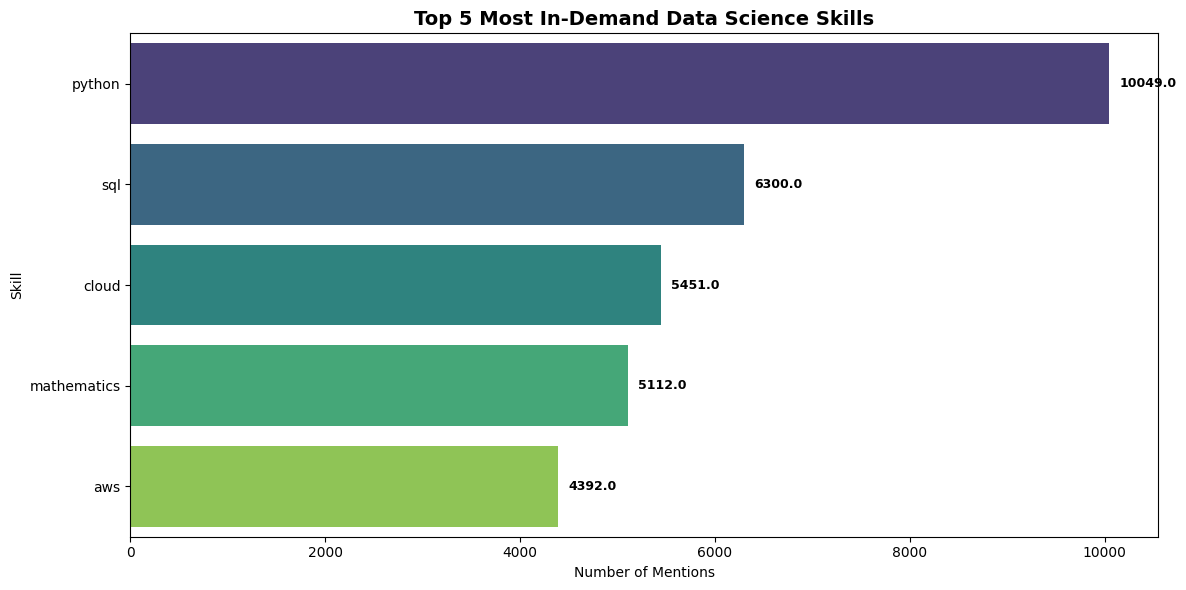

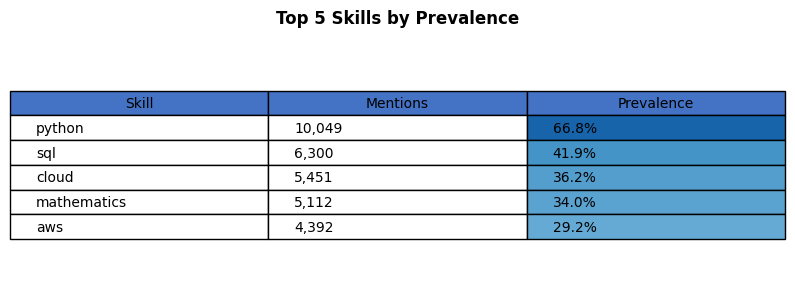

In [6]:
top_skills = analyzer.skill_analyzer.analyze_skill_frequency(pivot_df, top_n=5)

print("TOP 5 MOST IN-DEMAND SKILLS")
print("="*50)

# Create visualization
from src.visualizations.market_analysis_plot import MarketAnalysisPlot
market_plot = MarketAnalysisPlot()

market_plot.plot_skills_bar(top_skills, column='skill', top_n=5, 
                           title='Top 5 Most In-Demand Data Science Skills')

# Create a table visualization instead of using display()
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

table_data = []
for _, row in top_skills.head(5).iterrows():
    table_data.append([row['skill'], 
                      f"{row['mentions']:,}", 
                      f"{row['prevalence']:.1f}%"])

table = ax.table(cellText=table_data,
                 colLabels=['Skill', 'Mentions', 'Prevalence'],
                 cellLoc='left',
                 loc='center',
                 colColours=['#4472C4']*3)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color the prevalence column with gradient
for i, (_, row) in enumerate(top_skills.head(5).iterrows()):
    intensity = row['prevalence'] / top_skills['prevalence'].max()
    color = plt.cm.Blues(0.3 + 0.5 * intensity)
    table[(i+1, 2)].set_facecolor(color)

plt.title('Top 5 Skills by Prevalence', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. Seniority-Level Analysis
### 3.1 Skills by Seniority Level

SKILL DISTRIBUTION BY SENIORITY LEVEL


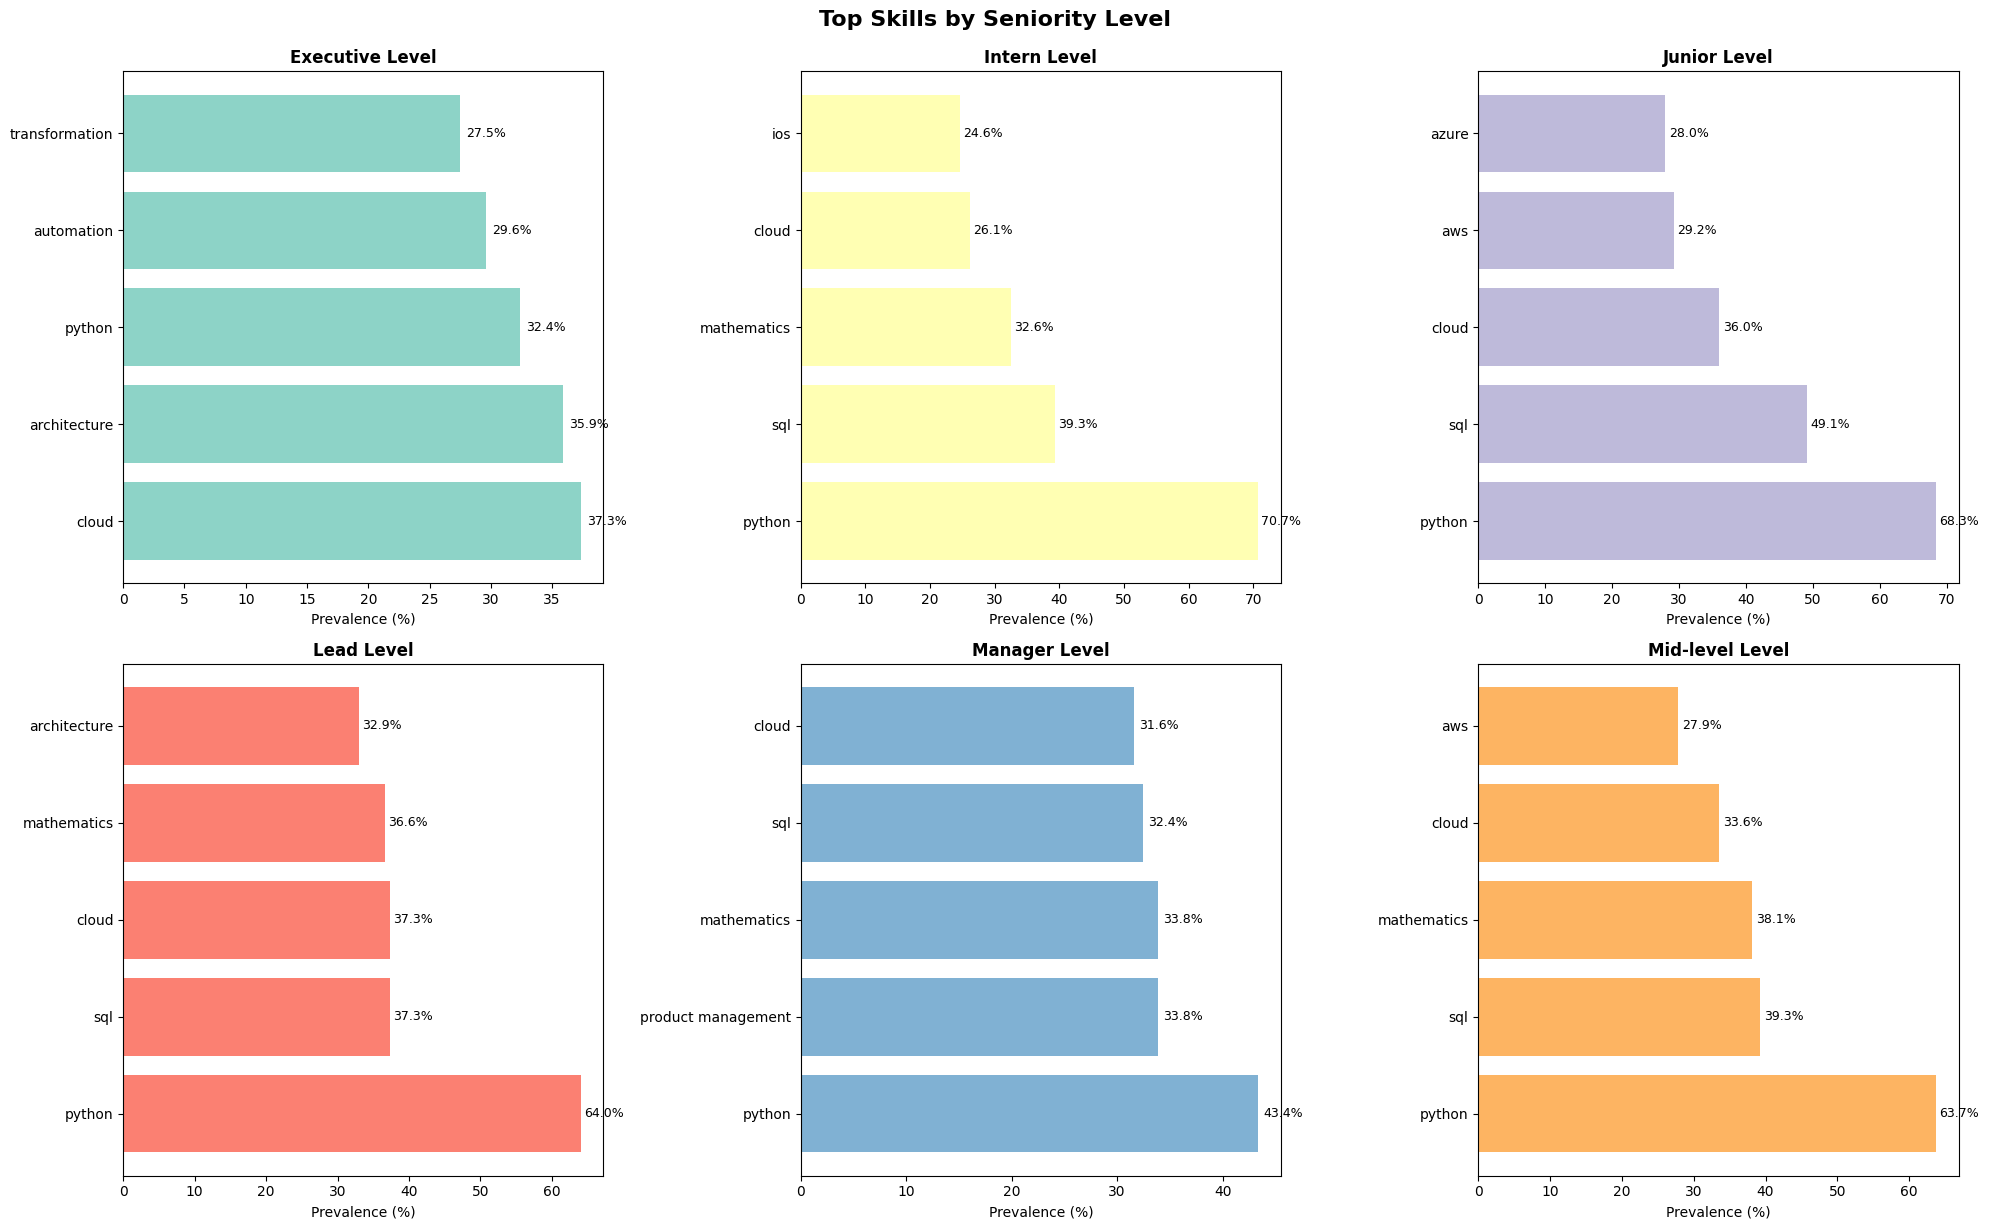

In [7]:
seniority_skills = analyzer.role_analyzer.analyze_skills_by_seniority(pivot_df, top_n=5)

print("SKILL DISTRIBUTION BY SENIORITY LEVEL")
print("="*55)

# Create visualization for each seniority level
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (level, skills_df) in enumerate(seniority_skills.items()):
    if idx < 6:  # Limit to first 6 seniority levels
        ax = axes[idx]
        top_skills = skills_df.head(5)
        
        ax.barh(top_skills['skill'], top_skills['prevalence'], color=plt.cm.Set3(idx))
        ax.set_title(f'{level} Level', fontweight='bold', fontsize=12)
        ax.set_xlabel('Prevalence (%)')
        
        # Add value labels
        for i, v in enumerate(top_skills['prevalence']):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Top Skills by Seniority Level', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 3.2 Seniority-Specific Skill Patterns

ANALYZING SENIORITY-SPECIFIC SKILL PATTERNS


INFO:src.analysis.seniority_analyzer:Identifying seniority-specific skill patterns...
Analyzing seniority patterns: 100%|██████████| 8/8 [00:07<00:00,  1.00it/s]
INFO:src.analysis.seniority_analyzer:
INFO:src.analysis.seniority_analyzer:SENIORITY-SPECIFIC SKILL PATTERNS INSIGHTS
INFO:src.analysis.seniority_analyzer:======================================================================
INFO:src.analysis.seniority_analyzer:
UNSPECIFIED LEVEL:
INFO:src.analysis.seniority_analyzer:   • Total jobs: 5,502
INFO:src.analysis.seniority_analyzer:   • Unique skills: 301
INFO:src.analysis.seniority_analyzer:   • Skill concentration: 0.348
INFO:src.analysis.seniority_analyzer:   • Top skills: python (72.6%), sql (45.3%), cloud (37.6%)
INFO:src.analysis.seniority_analyzer:   • Level-specific: No strongly specific skills identified
INFO:src.analysis.seniority_analyzer:
INTERN LEVEL:
INFO:src.analysis.seniority_analyzer:   • Total jobs: 820
INFO:src.analysis.seniority_analyzer:   • Unique skills: 253


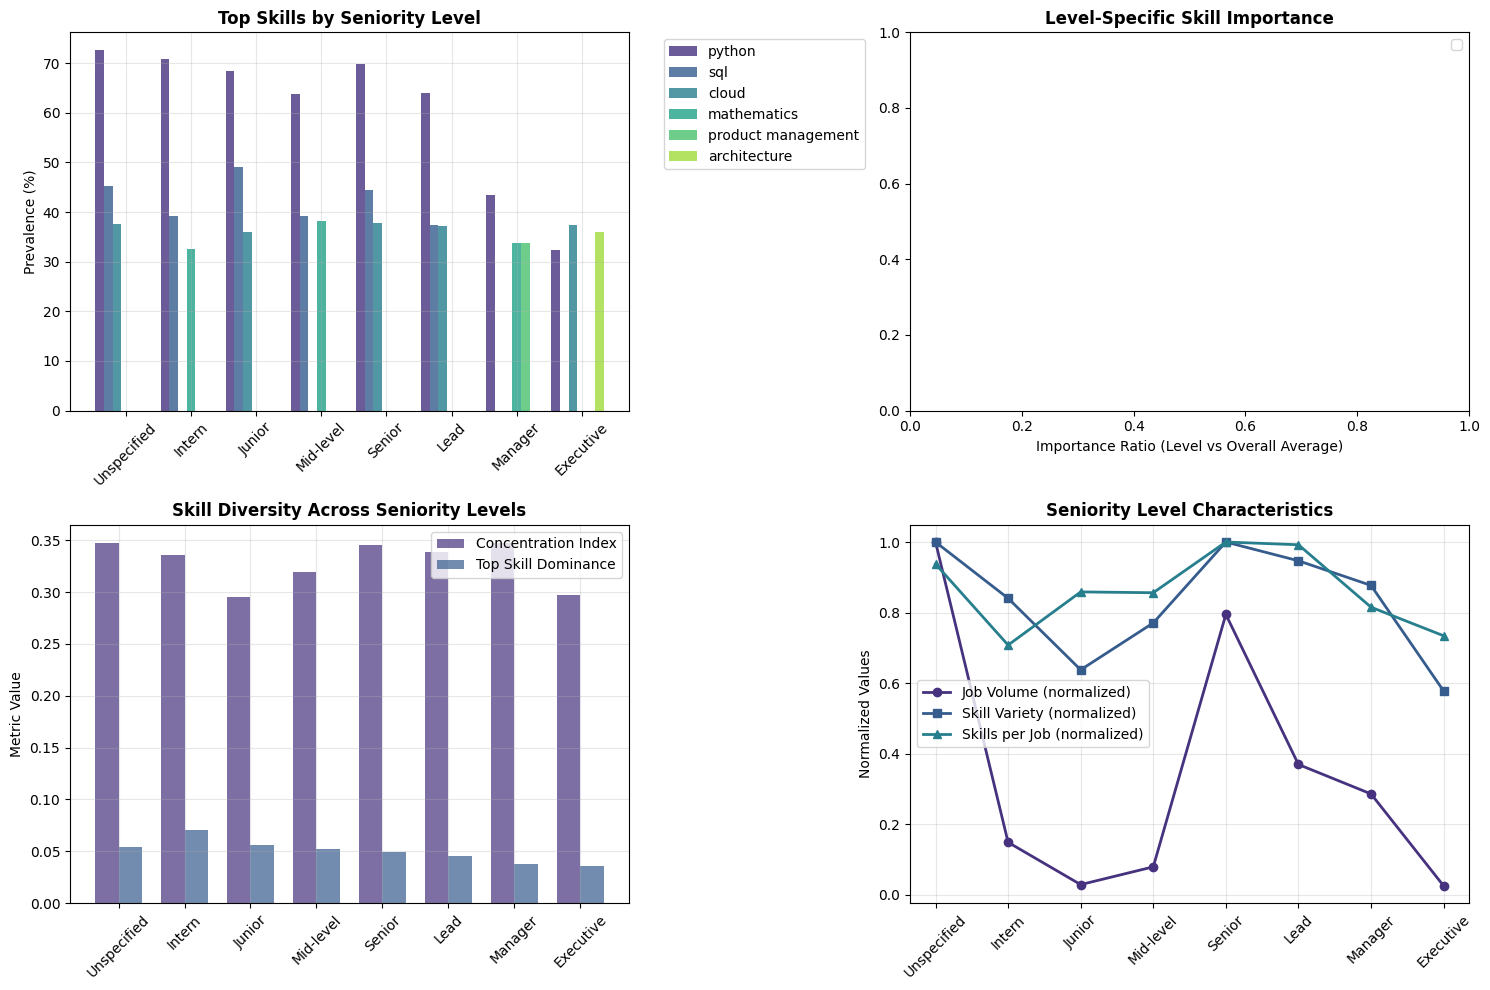

In [8]:
# Identify seniority-specific patterns
print("ANALYZING SENIORITY-SPECIFIC SKILL PATTERNS")
print("="*55)

# Get progression data for key skills
key_skills = ['Python', 'SQL', 'Machine Learning', 'AWS', 'Tableau', 'Spark']
progression_data = analyzer.role_analyzer.analyze_skill_progression_data(pivot_df, key_skills)

# Analyze patterns using seniority analyzer
seniority_patterns = analyzer.seniority_analyzer.analyze_seniority_specific_patterns(
    pivot_df, progression_data
)

# Create visualization
market_plot.plot_seniority_patterns(seniority_patterns)

### 3.3 Skill Progression Across Career Levels

In [9]:
print("SKILL PROGRESSION ACROSS CAREER LEVELS")
print("="*50)
 
from src.visualizations.role_analysis_plot import RoleAnalysisPlot
role_plot = RoleAnalysisPlot()

role_plot.plot_skill_progression_organized(progression_data)

# Additional simple view for key technical skills
technical_skills = ['Python', 'Machine Learning', 'Spark', 'AWS', 'TensorFlow', 'Kubernetes']
tech_progression = analyzer.role_analyzer.analyze_skill_progression_data(pivot_df, technical_skills)

print("\nTechnical Skill Progression:")
role_plot.plot_skill_progression_simple(tech_progression)

SKILL PROGRESSION ACROSS CAREER LEVELS

Technical Skill Progression:


## 4. Role-Based Analysis
### 4.1 Skills by Job Role 

SKILL PROFILES BY JOB ROLE


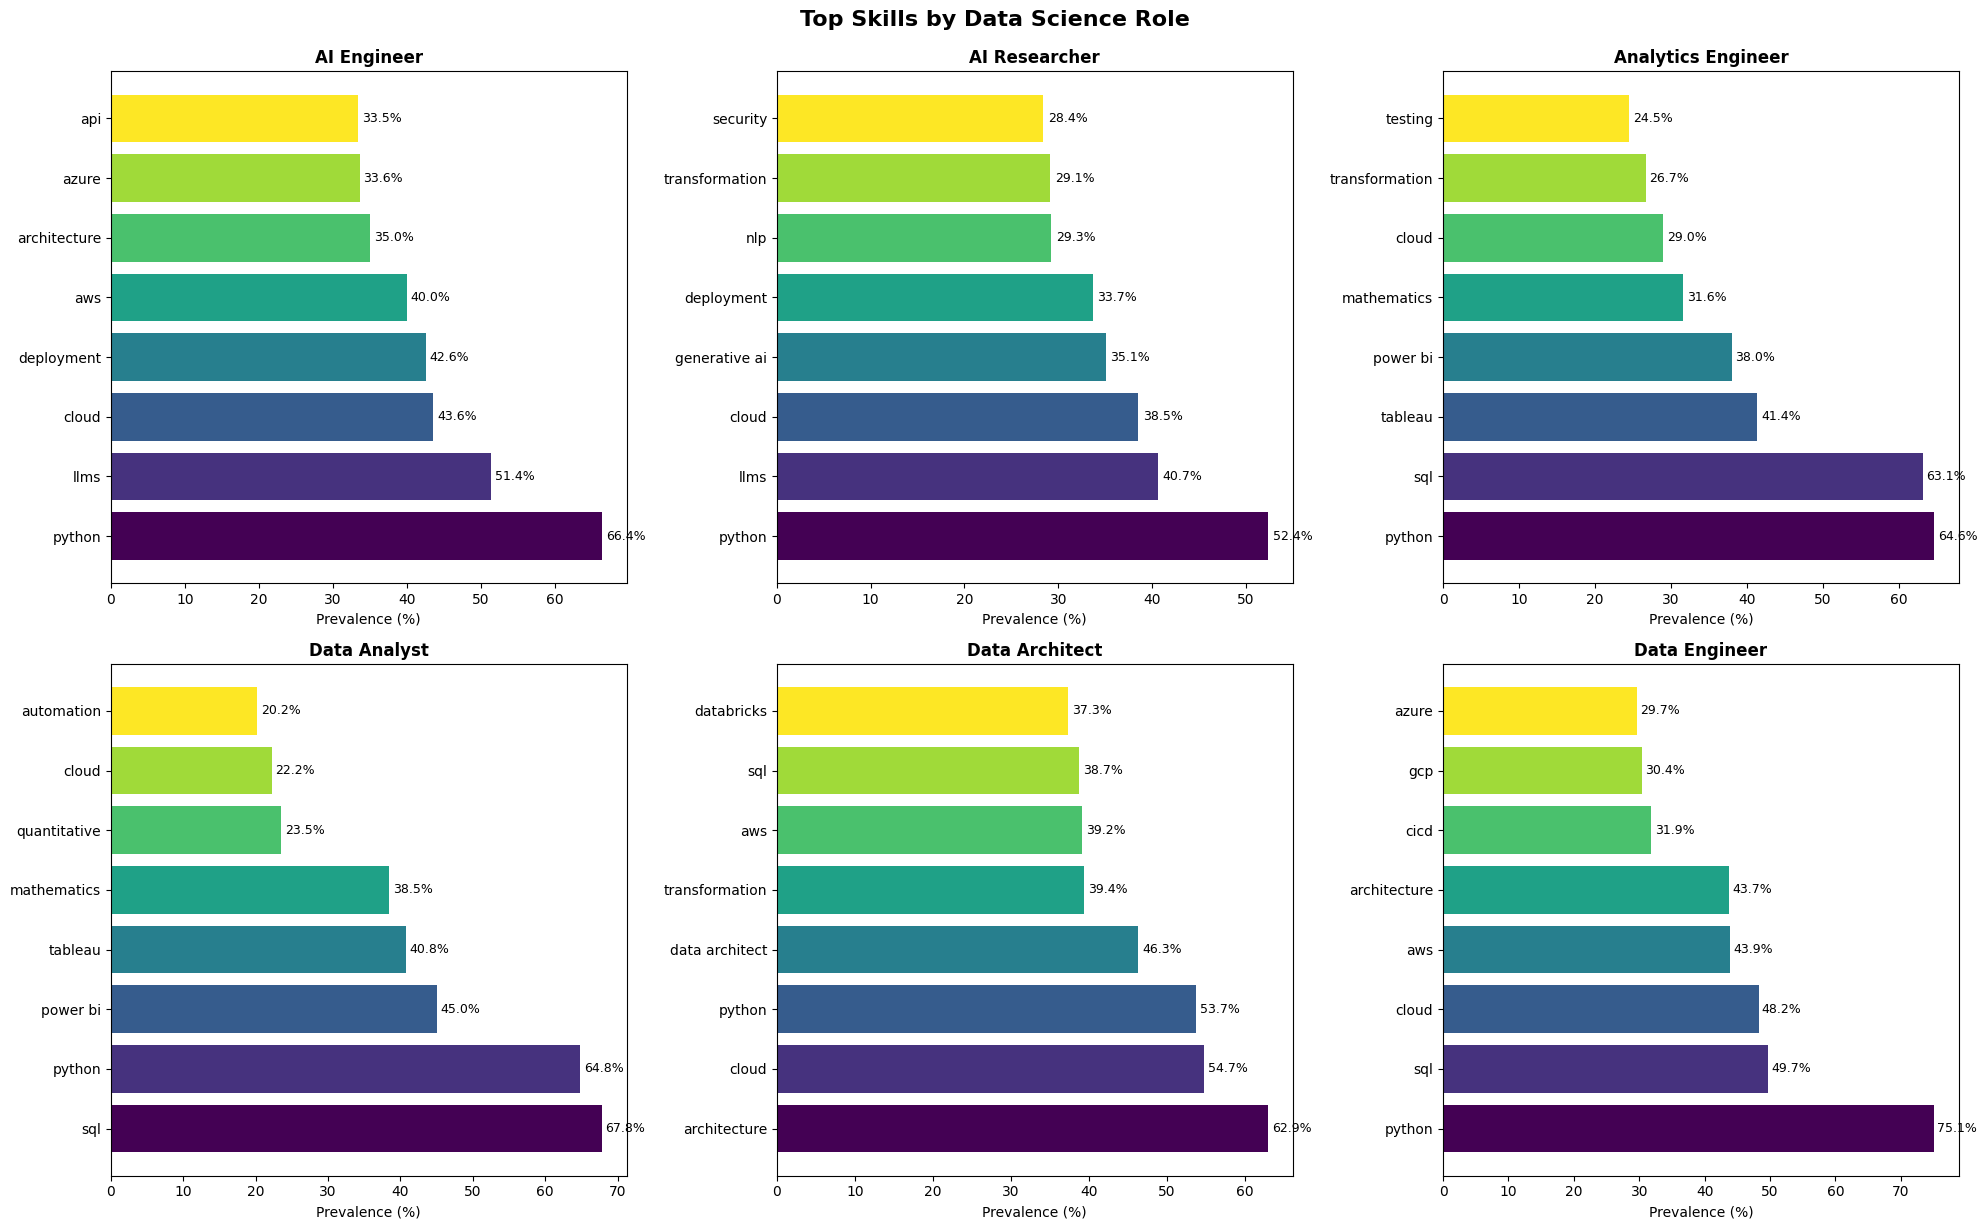

In [10]:
# Analyze skills for different data roles
role_skills = analyzer.role_analyzer.analyze_skills_by_role(pivot_df, top_n=12)

print("SKILL PROFILES BY JOB ROLE")
print("="*40)

# Visualize top roles
top_roles = list(role_skills.keys())[:6]  # Show first 6 roles

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, role in enumerate(top_roles):
    if idx < 6:
        ax = axes[idx]
        role_data = role_skills[role].head(8)
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(role_data)))
        ax.barh(role_data['skill'], role_data['prevalence'], color=colors)
        ax.set_title(f'{role}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Prevalence (%)')
        
        # Add value labels
        for i, v in enumerate(role_data['prevalence']):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Top Skills by Data Science Role', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### 4.2 Role Comparison Matrix

ROLE SKILL PROFILE COMPARISON


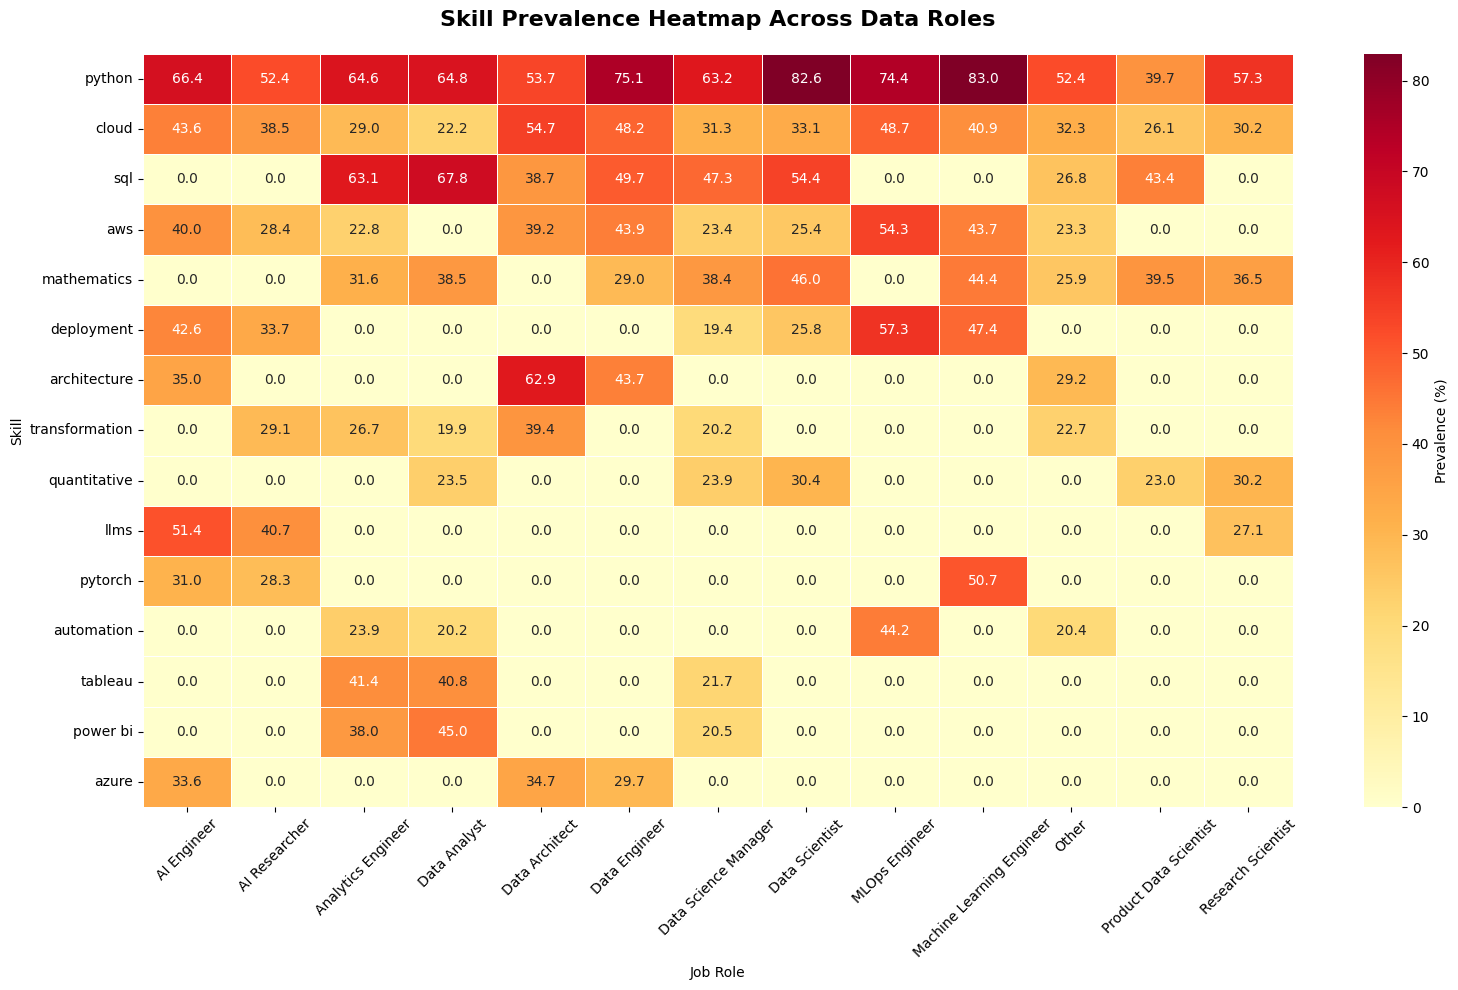


Key Observations:
• Roles with distinct skill profiles are clearly visible
• Universal skills appear across multiple roles
• Role-specific specializations are evident


In [11]:
# Compare skill profiles across roles
print("ROLE SKILL PROFILE COMPARISON")
print("="*45)

role_comparison = analyzer.role_analyzer.compare_role_skill_profiles(pivot_df)

# Create heatmap for role comparison
plt.figure(figsize=(16, 10))

# Select top skills for visualization
top_skills_comparison = role_comparison.mean(axis=1).nlargest(15).index
comparison_vis = role_comparison.loc[top_skills_comparison]

# Create heatmap
sns.heatmap(comparison_vis, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Prevalence (%)'})
plt.title('Skill Prevalence Heatmap Across Data Roles', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Role')
plt.ylabel('Skill')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("• Roles with distinct skill profiles are clearly visible")
print("• Universal skills appear across multiple roles")
print("• Role-specific specializations are evident")

## 5. Enhanced Skill Trend Analysis Execution


In [12]:
print("Running skill trend analysis with mentions integration...")
results = analyzer.trend_analyzer.analyze_skill_trends_enhanced(
    pivot_df, 
    min_prevalence=1.0, 
    min_avg_mentions=5,
    min_months=8,
    smoothing_alpha=0.3
)

print(f"Analysis complete! Found {len(results)} skills meeting criteria")
print("\nTop 10 skills by volume-adjusted score:")
display(results.head(10)[['skill', 'volume_adjusted_score', 'trend_category', 'current_prevalence', 'avg_mentions_per_month']])

Running skill trend analysis with mentions integration...
Analysis complete! Found 166 skills meeting criteria

Top 10 skills by volume-adjusted score:


,skill,volume_adjusted_score,trend_category,current_prevalence,avg_mentions_per_month
0,http,2700.820687,Stable & In-Demand,5.333355,48.538462
1,conversational ai,1749.914134,Emerging & New,1.785396,19.923077
2,grafana,1519.937024,Niche & Specialized,1.117318,14.230769
3,seaborn,1378.005992,Emerging & New,0.905691,12.769231
4,servers,1347.312380,Niche & Specialized,0.905048,11.692308
5,applied ml,1254.923489,Niche & Specialized,2.240418,22.000000
6,ruby on rails,423.588829,Stable & In-Demand,3.253142,29.000000
7,embeddings,359.891799,Hot & Growing,6.139714,62.384615
8,html,326.233112,Stable & In-Demand,4.408390,45.000000
9,oracle,266.816680,Stable & In-Demand,3.492148,38.923077


### 5.1 Plot Trend Categories Distribution


Plotting trend categories distribution...


INFO:src.visualizations.trends_plot:Saved trend categories plot to: ..\reports\figures\trend_categories_distribution_20260402_171218.jpg


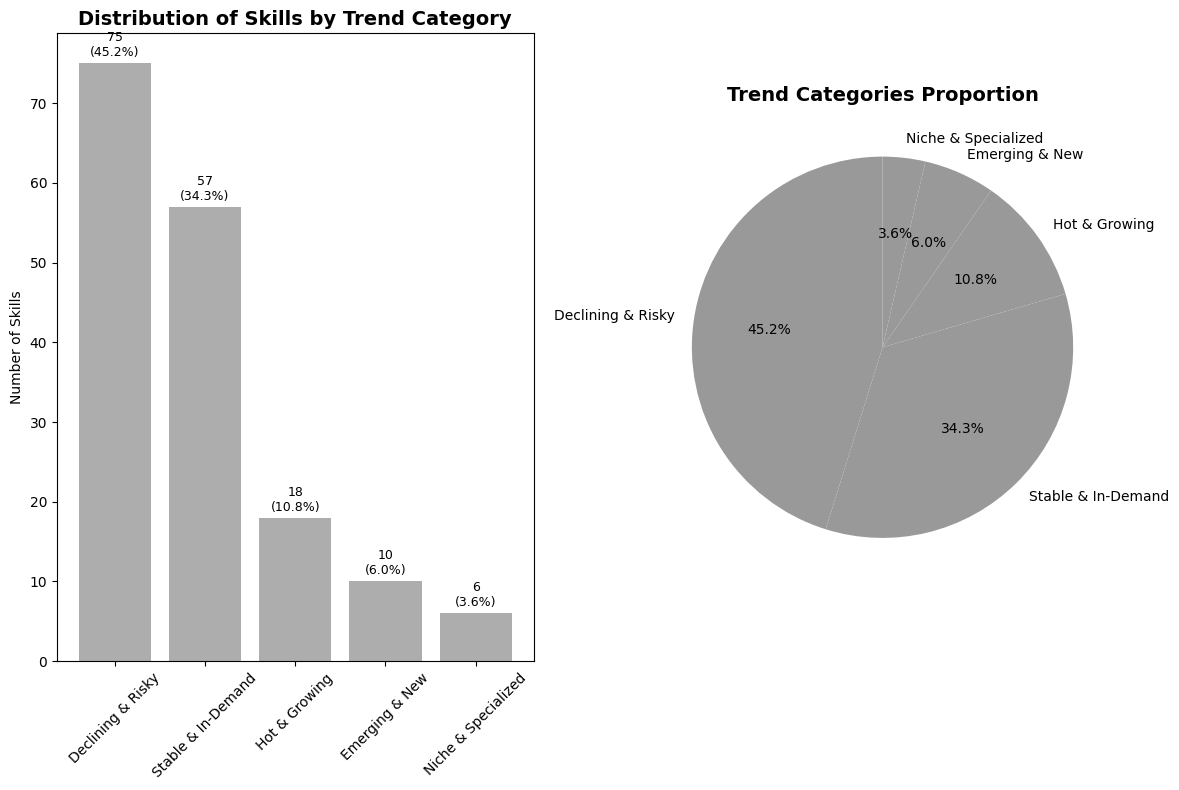

In [13]:
from src.visualizations.trends_plot import TrendsAnalysisPlot
trends_plot = TrendsAnalysisPlot()

print("Plotting trend categories distribution...")
fig1 = trends_plot.plot_trend_categories_distribution(results)
plt.show()

### 5.2 Plot Scatter Matrix of Key Metrics

Plotting scatter matrix of key metrics...


INFO:src.visualizations.trends_plot:Saved scatter matrix plot to: ..\reports\figures\trend_scatter_matrix_20260402_171224.jpg


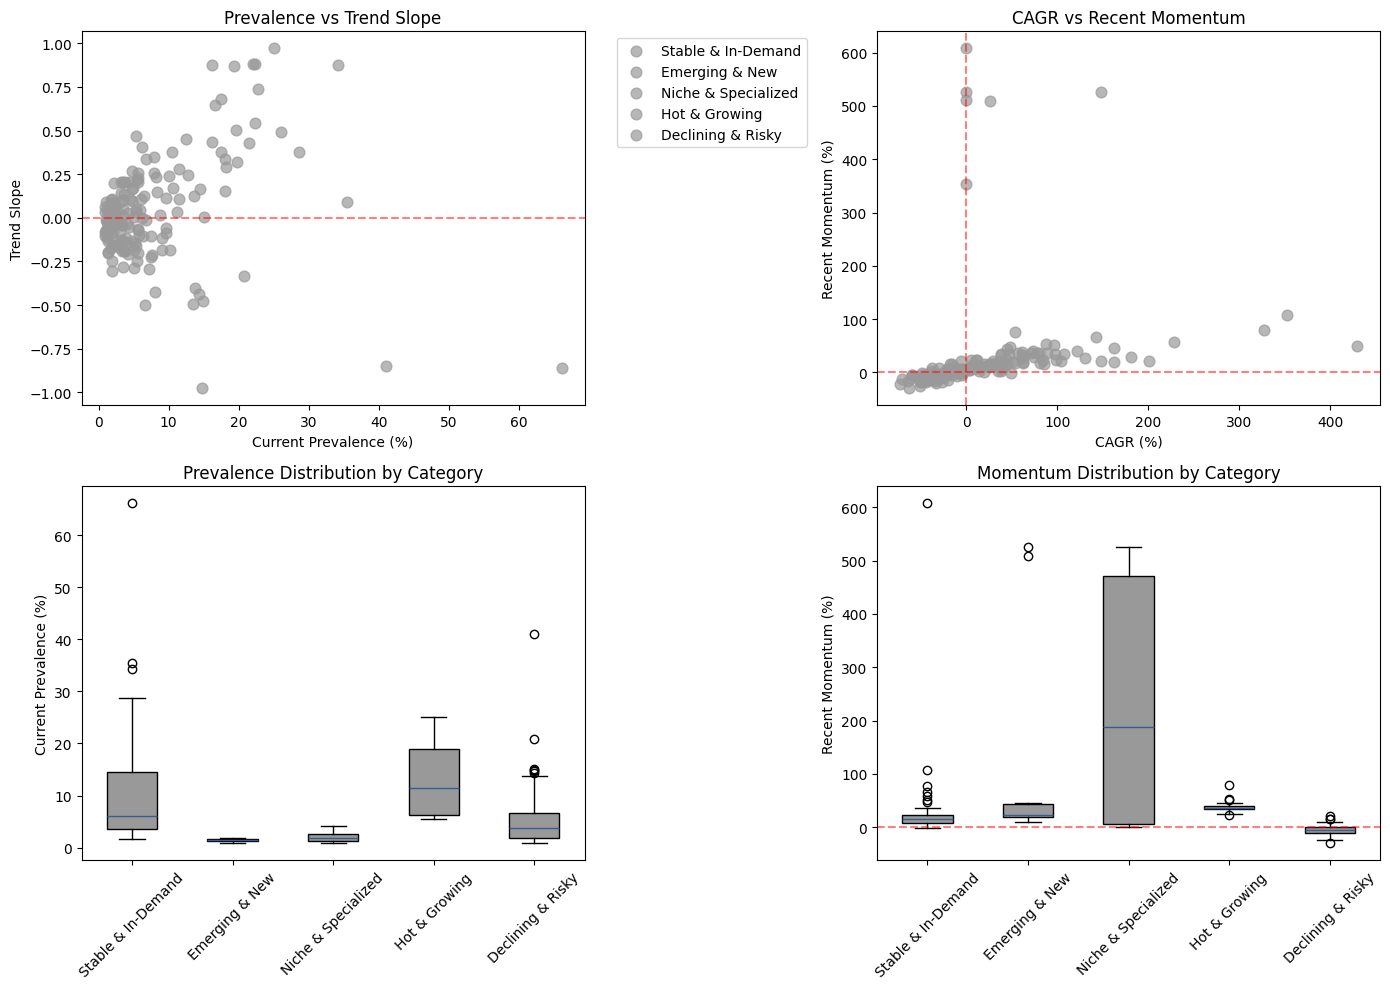

In [14]:
print("Plotting scatter matrix of key metrics...")
fig2 = trends_plot.plot_trend_scatter_matrix(results)
plt.show()

### 5.3  Plot Emerging vs Declining Skills

Plotting emerging vs declining skills...


INFO:src.visualizations.trends_plot:Saved emerging vs declining plot to: ..\reports\figures\emerging_vs_declining_20260402_171230.jpg


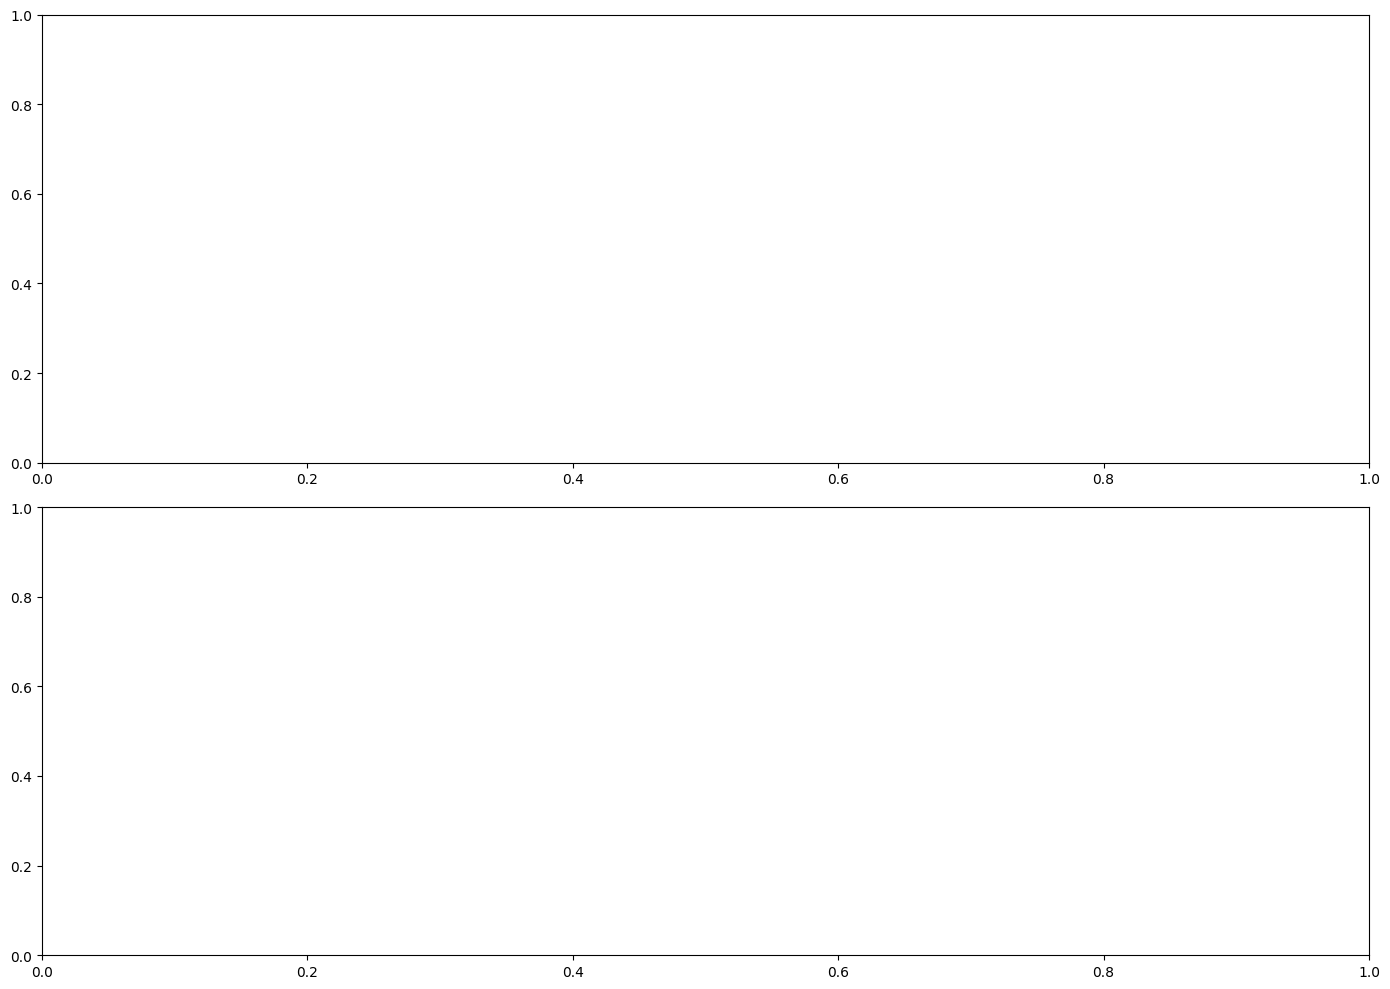

In [15]:
print("Plotting emerging vs declining skills...")
fig3 = trends_plot.plot_emerging_vs_declining_skills(results, top_n=15)
plt.show()

### 5.4  Plot Skill Trend Timelines

In [16]:
if not results.empty:
    # Get top emerging and declining skills for timeline plotting
    top_emerging = results[results['is_emerging']].nlargest(3, 'volume_adjusted_score')
    top_declining = results[results['is_declining']].nsmallest(3, 'volume_adjusted_score')
    top_growing = results[results['is_growing']].nlargest(2, 'volume_adjusted_score')
    
    skills_to_plot = list(top_emerging['skill']) + list(top_declining['skill']) + list(top_growing['skill'])
    
    print(f"Plotting timelines for skills: {skills_to_plot}")
    fig4 = trends_plot.plot_skill_trend_timeline(pivot_df, skills_to_plot)
    plt.show()

Plotting timelines for skills: []
No skills specified


### 5.5 High-Confidence Trends Analysis

Plotting high-confidence emerging vs declining skills...


INFO:src.visualizations.trends_plot:Saved emerging vs declining plot to: ..\reports\figures\emerging_vs_declining_20260402_171234.jpg


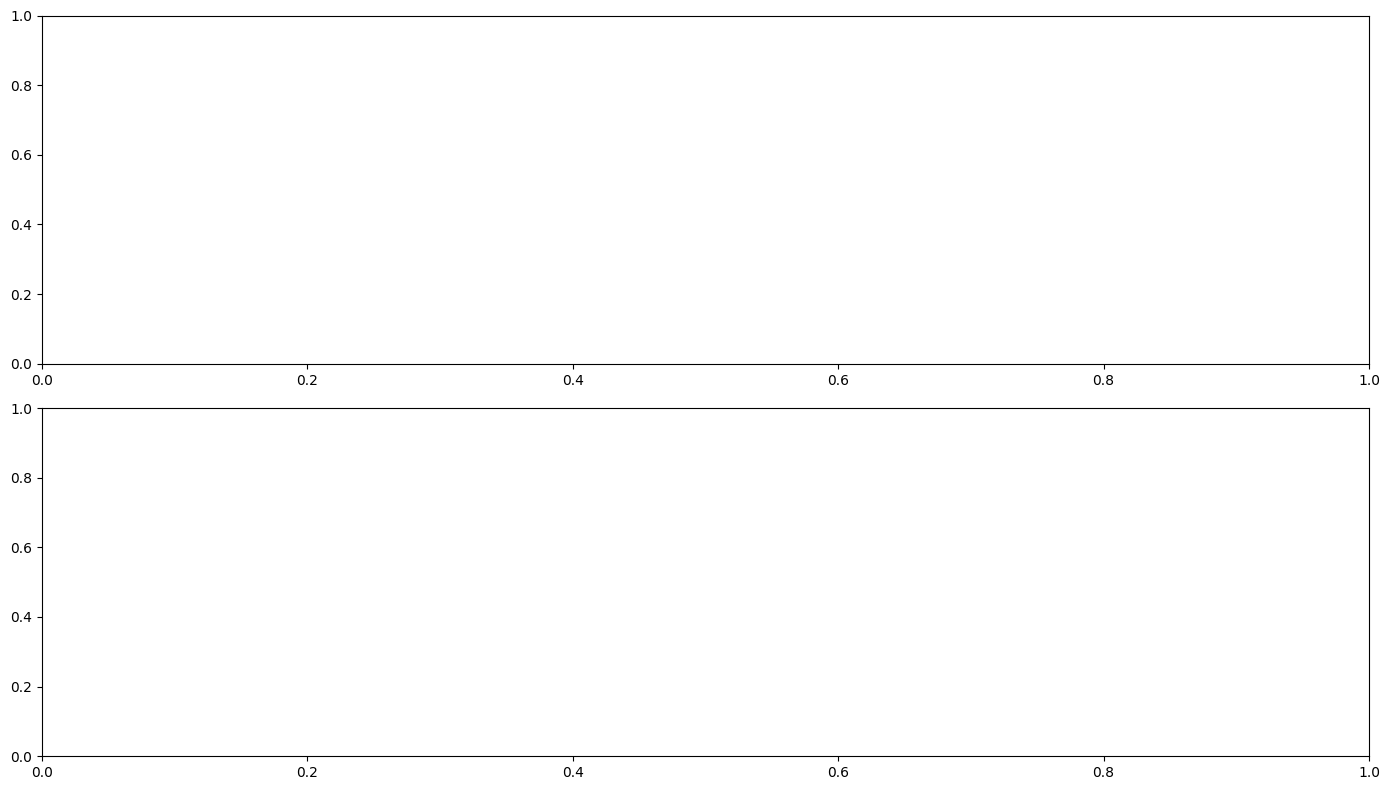

In [17]:
print("Plotting high-confidence emerging vs declining skills...")
fig5 = trends_plot.plot_emerging_vs_declining_skills(results, top_n=10, figsize=(14, 8))
plt.show()

### 5.6 Trend Category Summary Analysis

In [18]:
# Analyze results by trend category
print("\n=== TREND CATEGORY SUMMARY ===")
category_summary = results.groupby('trend_category').agg({
    'skill': 'count',
    'current_prevalence': 'mean',
    'volume_adjusted_score': 'mean',
    'avg_mentions_per_month': 'mean',
    'total_mentions': 'mean'
}).round(2)

category_summary = category_summary.rename(columns={'skill': 'skill_count'})
display(category_summary)


=== TREND CATEGORY SUMMARY ===


,skill_count,current_prevalence,volume_adjusted_score,avg_mentions_per_month,total_mentions
trend_category,,,,,
Declining & Risky,75,5.52,-20.80,65.40,850.17
Emerging & New,10,1.45,374.41,17.40,226.20
Hot & Growing,18,13.11,197.98,142.65,1854.50
Niche & Specialized,6,2.11,699.69,23.33,303.33
Stable & In-Demand,57,10.74,135.27,123.56,1606.23


### 5.8 Category-Specific Timeline Analysis

Plotting timelines for accelerating skills: ['embeddings', 'sme', 'prompt engineering']


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

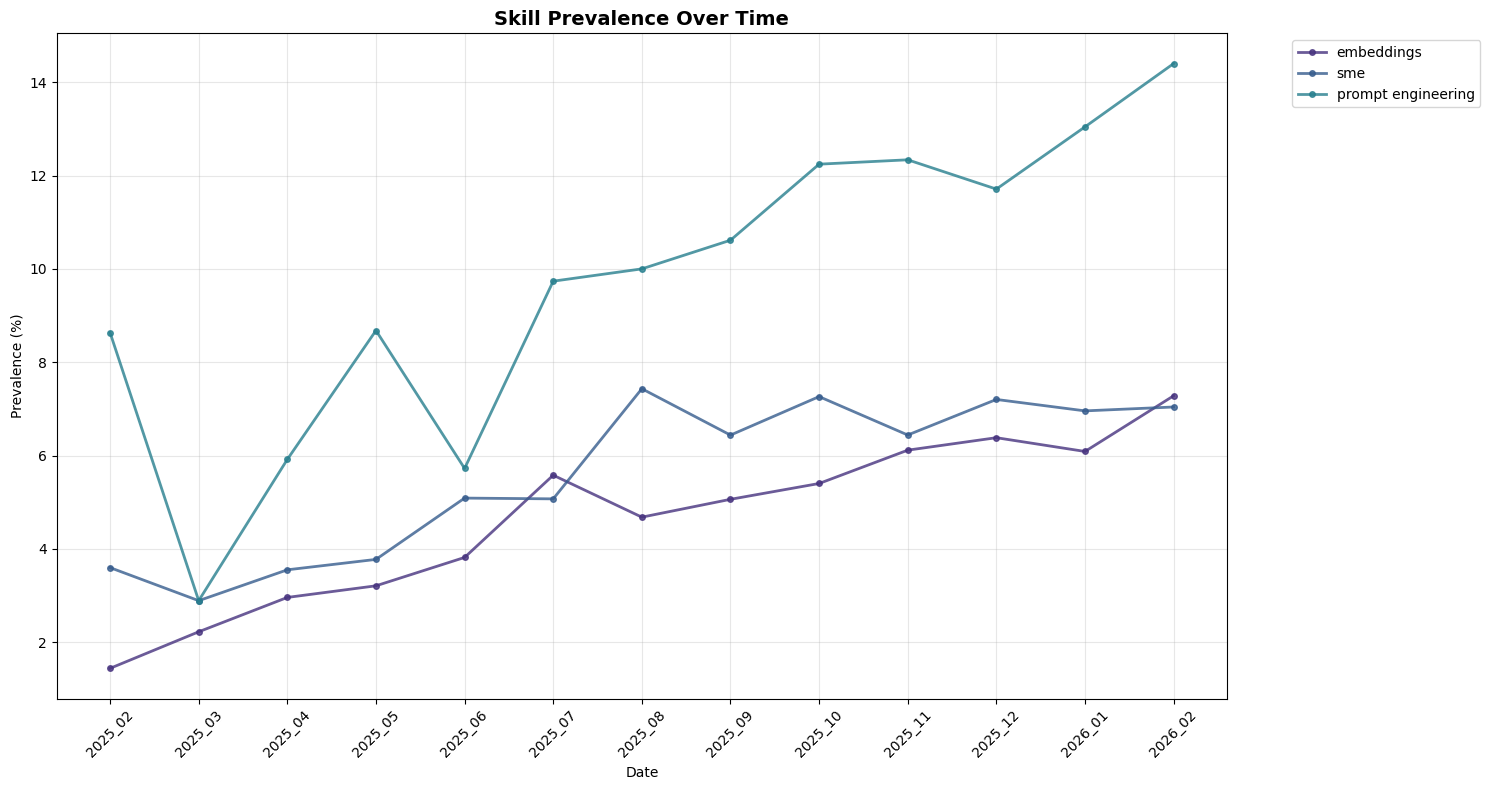

Plotting timelines for peaking skills: ['frontend', 'ms office', 'applied ml']


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

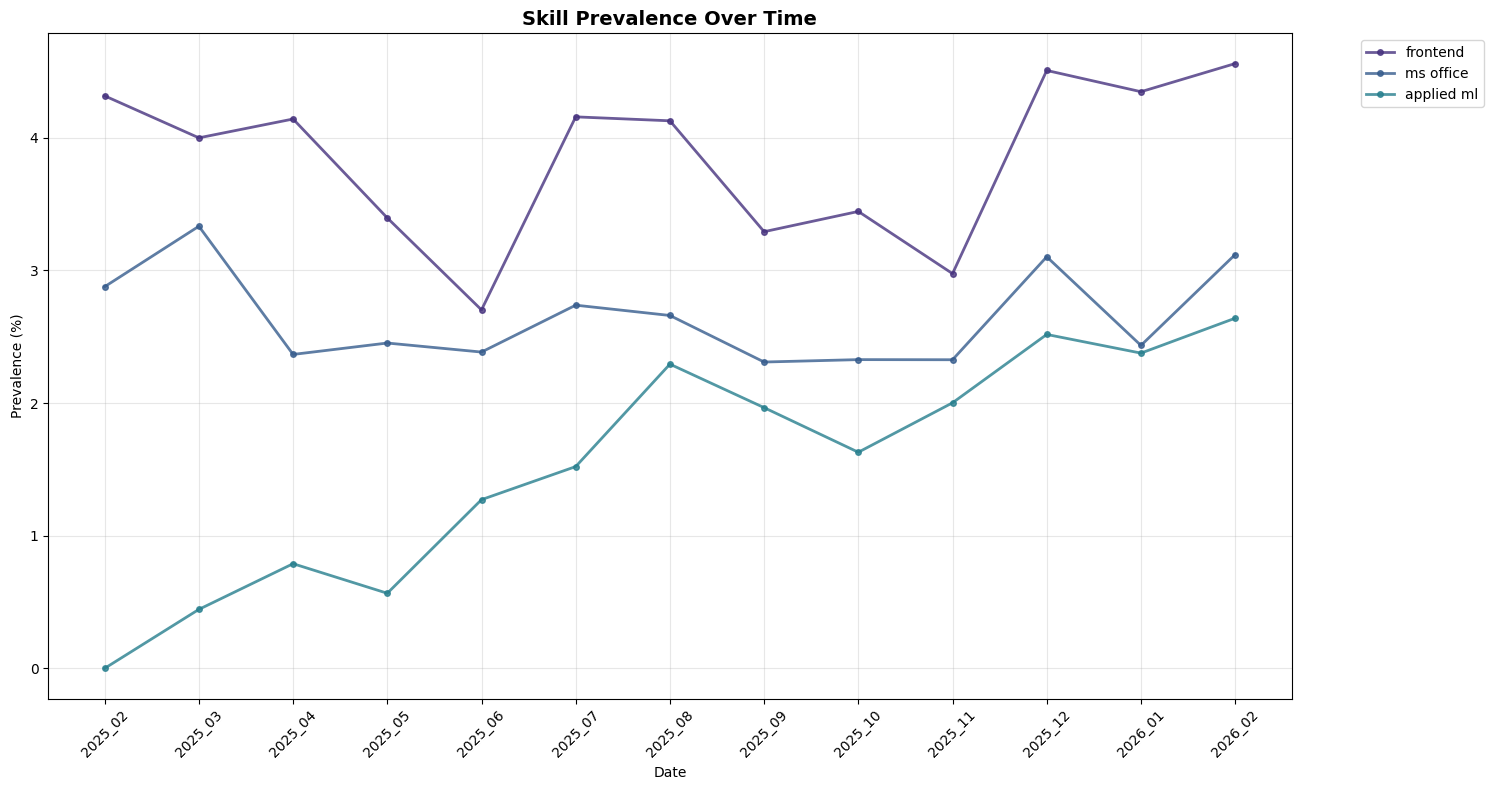

In [19]:
if not results.empty:
    # Plot timelines for top accelerating skills
    accelerating_skills = results[results['trend_category'] == 'Hot & Growing']
    if not accelerating_skills.empty:
        top_accelerating = accelerating_skills.nlargest(3, 'volume_adjusted_score')
        print(f"Plotting timelines for accelerating skills: {list(top_accelerating['skill'])}")
        fig6 = trends_plot.plot_skill_trend_timeline(pivot_df, list(top_accelerating['skill']));
        plt.show();
    
    # Plot timelines for peaking skills
    peaking_skills = results[results['trend_category'] == 'Niche & Specialized']
    if not peaking_skills.empty:
        top_peaking = peaking_skills.nlargest(3, 'current_prevalence')
        print(f"Plotting timelines for peaking skills: {list(top_peaking['skill'])}")
        fig7 = trends_plot.plot_skill_trend_timeline(pivot_df, list(top_peaking['skill']));
        plt.show();

### 5.9 Final Summary Report

In [20]:
# Final summary report
print("\n=== FINAL SUMMARY REPORT ===")
print(f"Total skills analyzed: {len(results)}")
print(f"Skills by trend category: {results['trend_category'].value_counts()}")

# Average metrics
print(f"\nAverage current prevalence: {results['current_prevalence'].mean():.2f}%")
print(f"Average monthly mentions: {results['avg_mentions_per_month'].mean():.2f}")
print(f"Average volume-adjusted score: {results['volume_adjusted_score'].mean():.2f}")


=== FINAL SUMMARY REPORT ===
Total skills analyzed: 166
Skills by trend category: trend_category
Declining & Risky      75
Stable & In-Demand     57
Hot & Growing          18
Emerging & New         10
Niche & Specialized     6
Name: count, dtype: int64

Average current prevalence: 7.77%
Average monthly mentions: 89.33
Average volume-adjusted score: 106.37


## 6. Skill Ecosystem Analysis
### 6.1 Skill Combinations and Clusters

SKILL COMBINATIONS AND NATURAL CLUSTERS


Processing combinations: 100%|██████████| 30/30 [00:00<00:00, 214.28it/s]



TOP SKILL COMBINATIONS
------------------------------


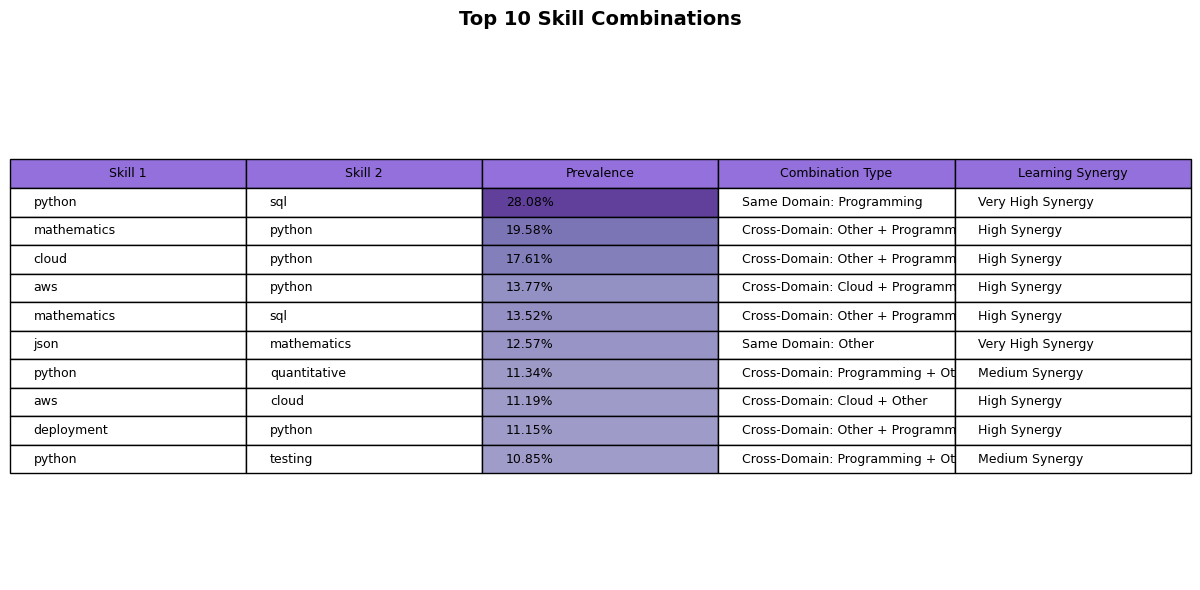

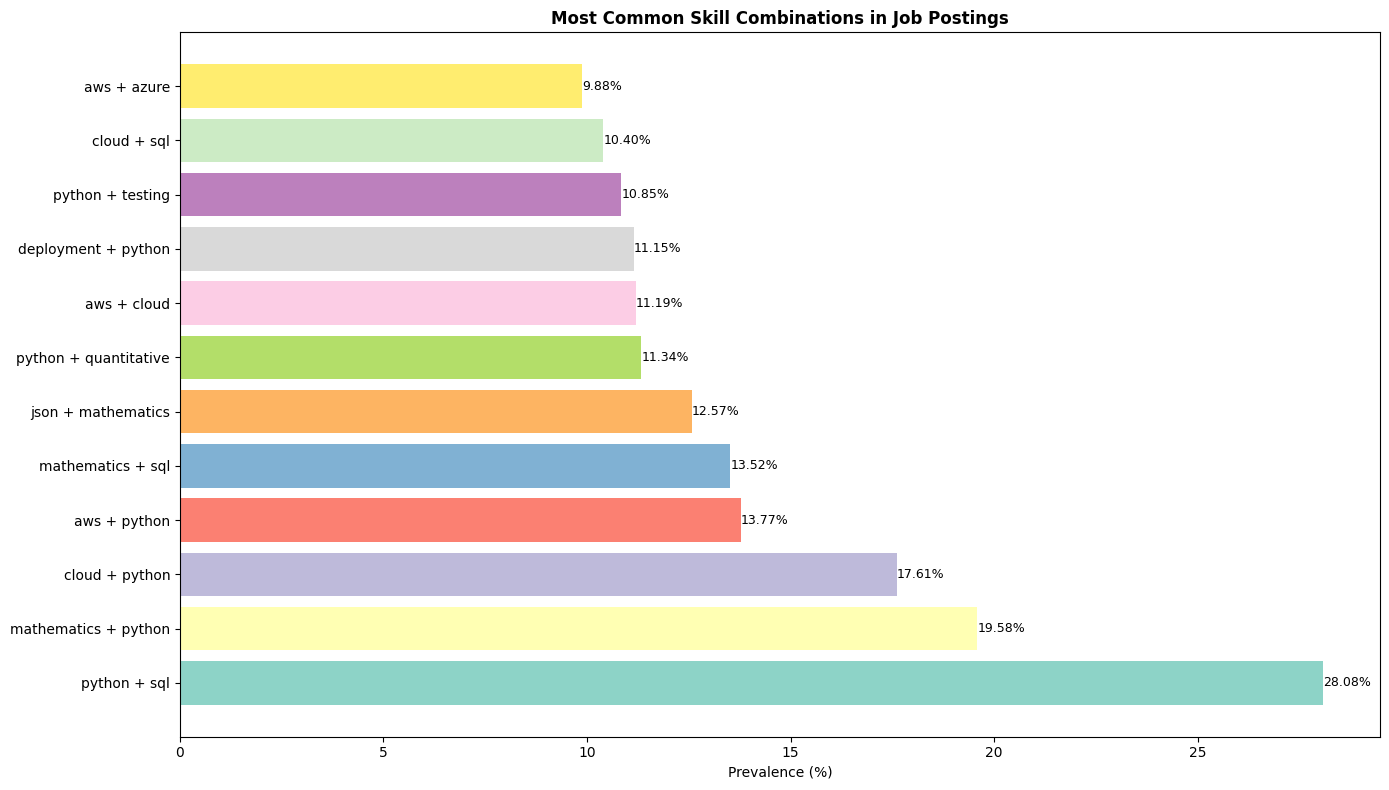

In [21]:
print("SKILL COMBINATIONS AND NATURAL CLUSTERS")
print("="*55)

# Analyze common skill combinations
skill_combinations = analyzer.skill_analyzer.analyze_skill_combination_prevalence(pivot_df, top_n=15)

if not skill_combinations.empty:
    print("\nTOP SKILL COMBINATIONS")
    print("-" * 30)
    
    # Display combination table 
    combo_display = skill_combinations[['skill_1', 'skill_2', 'prevalence', 'combination_type', 'learning_synergy']].head(10)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')

    # Prepare table data
    table_data = []
    for _, row in combo_display.iterrows():
        table_data.append([
            row['skill_1'],
            row['skill_2'],
            f"{row['prevalence']:.2f}%",
            row['combination_type'],
            row['learning_synergy']
        ])

    # Create table
    table = ax.table(cellText=table_data,
                    colLabels=['Skill 1', 'Skill 2', 'Prevalence', 'Combination Type', 'Learning Synergy'],
                    cellLoc='left',
                    loc='center',
                    colColours=['#9370DB'] * 5)

    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)

    # Color the prevalence column with gradient (Purples)
    prevalence_values = combo_display['prevalence'].values
    max_prevalence = prevalence_values.max() if len(prevalence_values) > 0 else 1

    for i, prev in enumerate(prevalence_values):
        intensity = prev / max_prevalence
        # Using purple colormap
        color = plt.cm.Purples(0.3 + 0.5 * intensity)
        table[(i+1, 2)].set_facecolor(color)

    plt.title('Top 10 Skill Combinations', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Visualize combinations
    plt.figure(figsize=(14, 8))
    top_combos = skill_combinations.head(12)
    
    # Create combination labels
    combo_labels = [f"{row['skill_1']} + {row['skill_2']}" for _, row in top_combos.iterrows()]
    
    plt.barh(combo_labels, top_combos['prevalence'], 
             color=plt.cm.Set3(np.linspace(0, 1, len(top_combos))))
    plt.xlabel('Prevalence (%)')
    plt.title('Most Common Skill Combinations in Job Postings', fontweight='bold')
    
    for i, v in enumerate(top_combos['prevalence']):
        plt.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

### 6.2 Natural Skill Clusters

INFO:src.analysis.ecosystem_analyzer:Fast Natural Skill Clusters Identification...



NATURAL SKILL CLUSTERS
------------------------------


Building clusters: 100%|██████████| 30/30 [00:00<00:00, 434.77it/s]


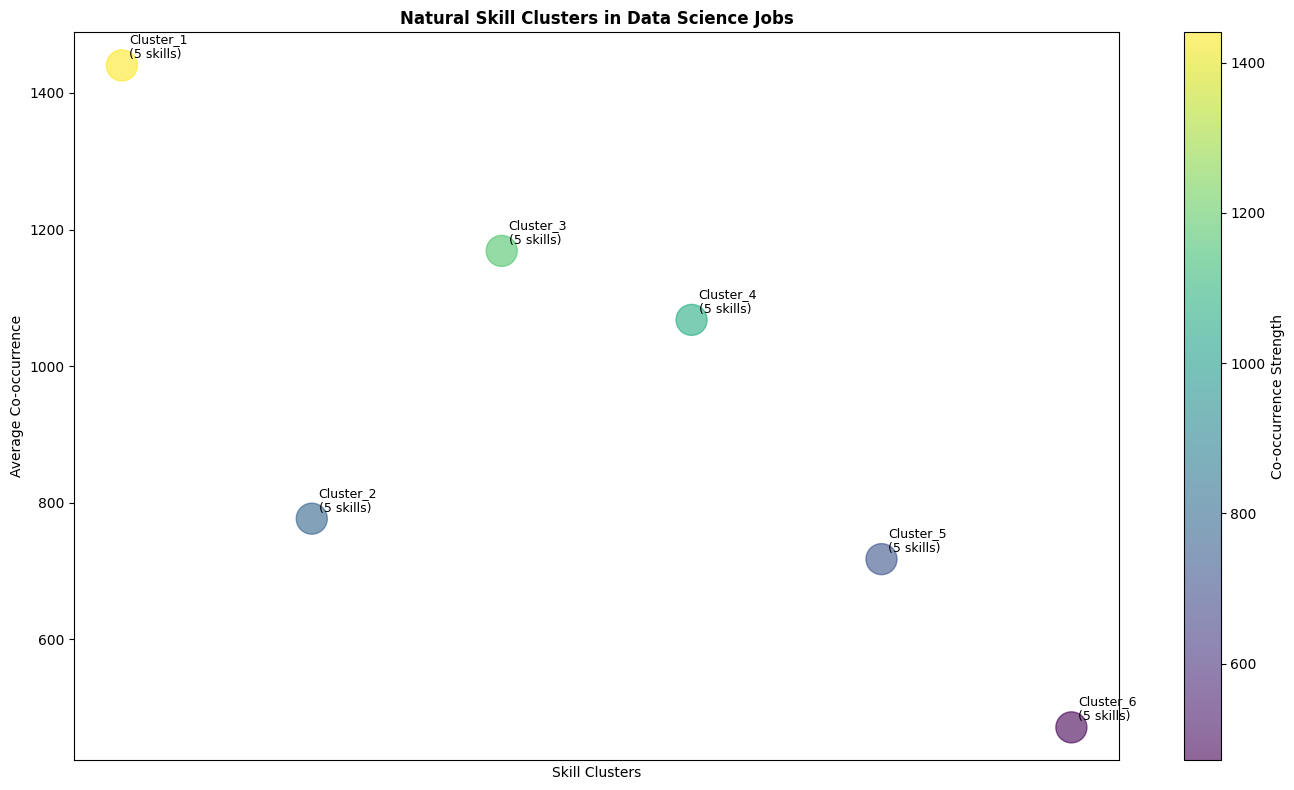


Cluster Details:

   Cluster_1:
      Core skill: tableau
      Skills: tableau, python, sql, power bi
      Avg co-occurrence: 1440.2

   Cluster_2:
      Core skill: ios
      Skills: ios, cloud, aws, deployment
      Avg co-occurrence: 776.8

   Cluster_3:
      Core skill: architecture
      Skills: architecture, azure, security, gcp
      Avg co-occurrence: 1168.8

   Cluster_4:
      Core skill: llms
      Skills: llms, generative ai, pytorch, api
      Avg co-occurrence: 1067.8

   Cluster_5:
      Core skill: automation
      Skills: automation, cicd, agile, infrastructure
      Avg co-occurrence: 717.5

   Cluster_6:
      Core skill: quantitative
      Skills: quantitative, product management, json, big data
      Avg co-occurrence: 471.2


In [22]:
print("\nNATURAL SKILL CLUSTERS")
print("-" * 30)

skill_clusters = analyzer.ecosystem_analyzer.identify_natural_skill_clusters(pivot_df)

if skill_clusters:
    # Visualize clusters
    fig, ax = plt.subplots(figsize=(14, 8))
    
    cluster_names = list(skill_clusters.keys())
    cluster_sizes = [len(cluster['skills']) for cluster in skill_clusters.values()]
    cluster_co_occurrence = [cluster['avg_co_occurrence'] for cluster in skill_clusters.values()]
    
    # Create bubble chart
    scatter = ax.scatter(range(len(cluster_names)), cluster_co_occurrence, 
                        s=[size*100 for size in cluster_sizes], alpha=0.6, 
                        c=cluster_co_occurrence, cmap='viridis')
    
    # Add labels
    for i, (name, size) in enumerate(zip(cluster_names, cluster_sizes)):
        ax.annotate(f"{name}\n({size} skills)", 
                   (i, cluster_co_occurrence[i]), 
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, ha='left')
    
    ax.set_xlabel('Skill Clusters')
    ax.set_ylabel('Average Co-occurrence')
    ax.set_title('Natural Skill Clusters in Data Science Jobs', fontweight='bold')
    plt.colorbar(scatter, label='Co-occurrence Strength')
    plt.xticks([])
    plt.tight_layout()
    plt.show()
    
    # Print cluster details
    print("\nCluster Details:")
    for cluster_name, cluster_data in list(skill_clusters.items())[:6]:
        print(f"\n   {cluster_name}:")
        print(f"      Core skill: {cluster_data['core_skill']}")
        print(f"      Skills: {', '.join(cluster_data['skills'][:4])}")
        print(f"      Avg co-occurrence: {cluster_data['avg_co_occurrence']:.1f}")

## 7. Regional and Company Analysis
### 7.1 Regional Skill Demand 

REGIONAL SKILL DEMAND VARIATIONS


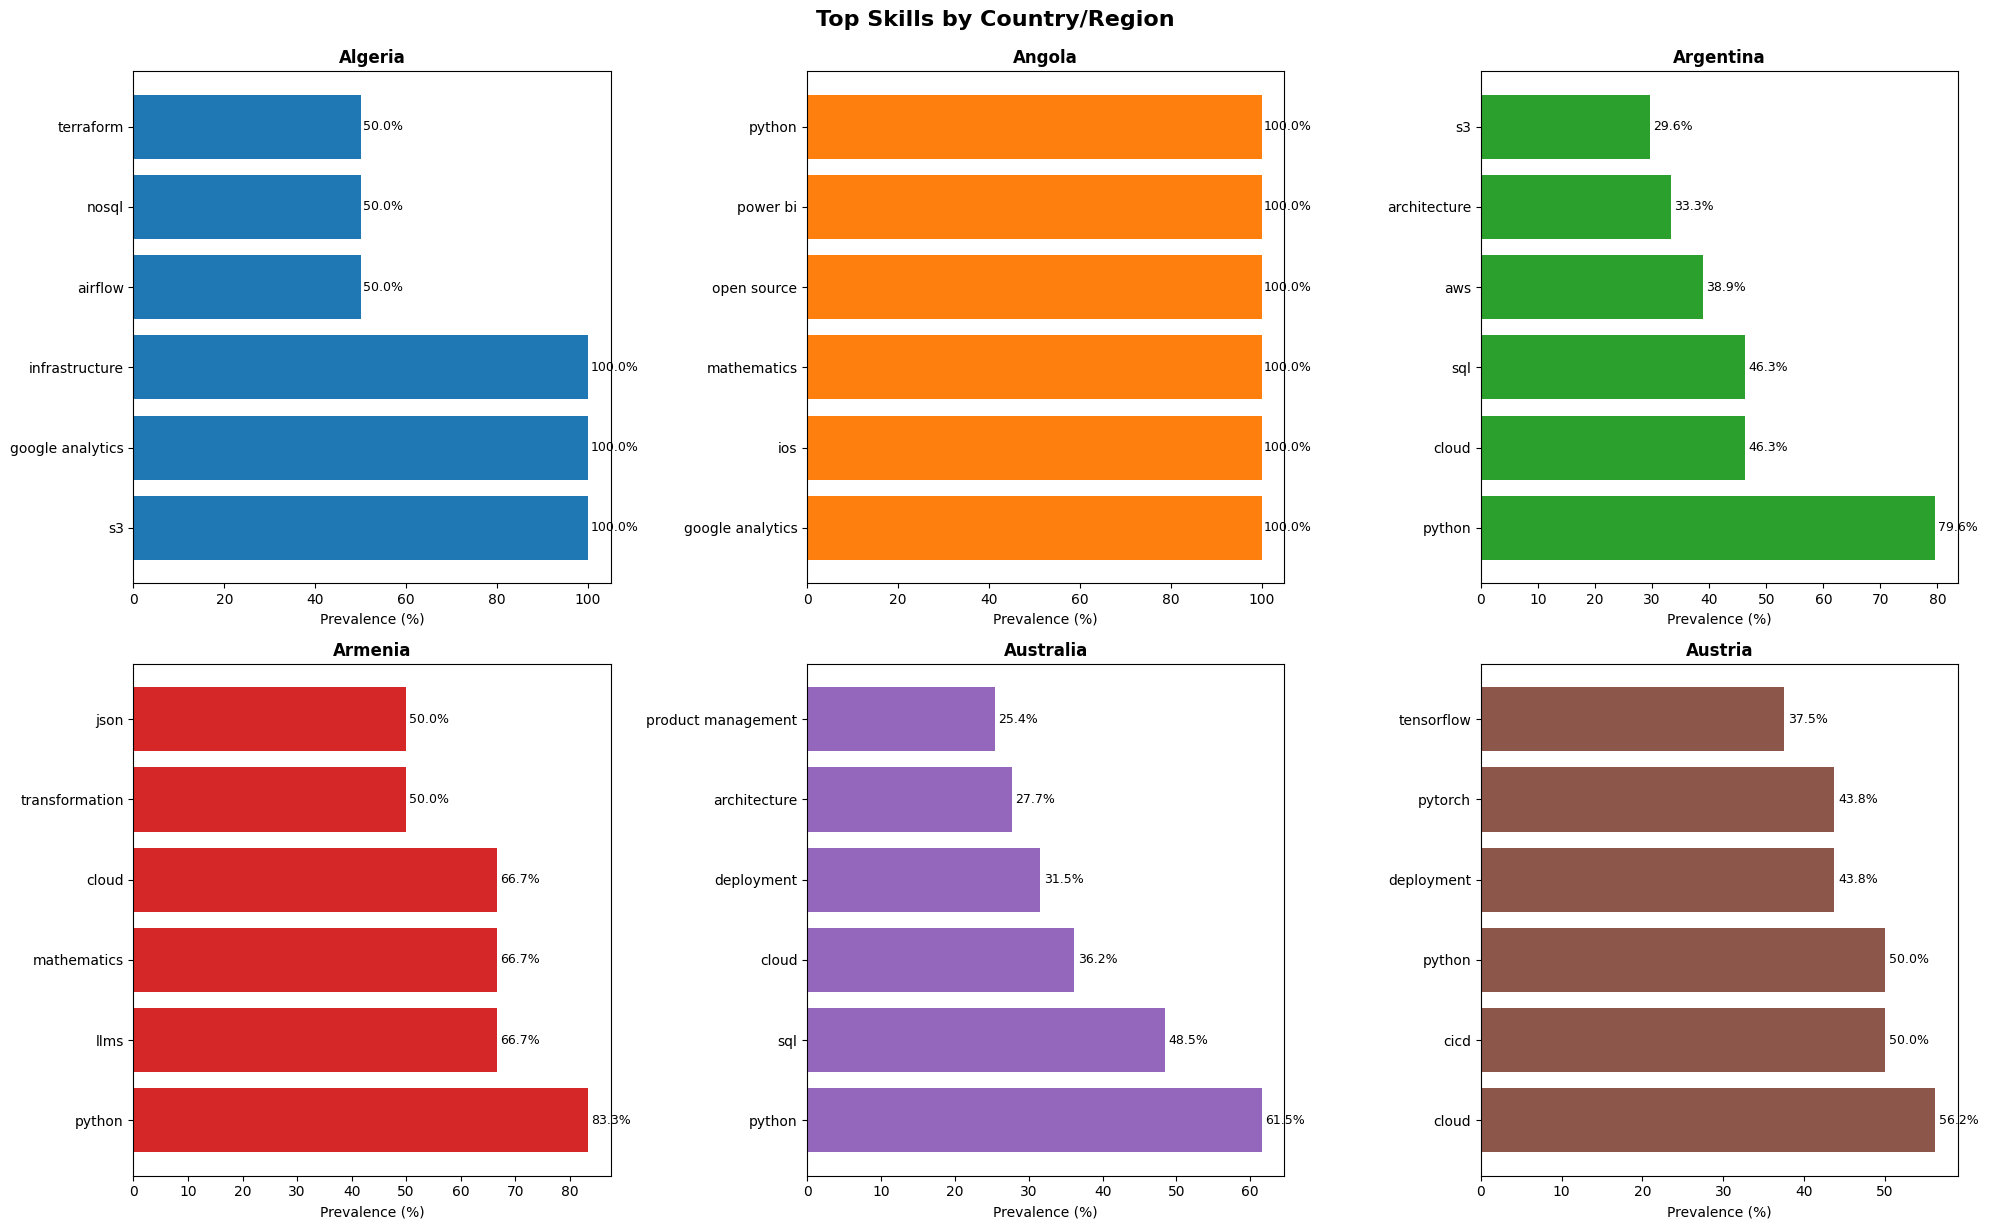

Regional Insights:
   • Algeria: s3 (100.0%)
   • Angola: google analytics (100.0%)
   • Argentina: python (79.6%)


In [23]:
# Analyze regional variations in skill demand
print("REGIONAL SKILL DEMAND VARIATIONS")
print("="*45)

regional_skills = analyzer.role_analyzer.analyze_regional_skill_demand(pivot_df, top_n=8)

if regional_skills:
    # Plot top countries
    top_countries = list(regional_skills.keys())[:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, country in enumerate(top_countries):
        if idx < 6:
            ax = axes[idx]
            country_data = regional_skills[country].head(6)
            
            ax.barh(country_data['skill'], country_data['prevalence'], 
                   color=plt.cm.tab10(idx))
            ax.set_title(f'{country}', fontweight='bold', fontsize=12)
            ax.set_xlabel('Prevalence (%)')
            
            for i, v in enumerate(country_data['prevalence']):
                ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.suptitle('Top Skills by Country/Region', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    print("Regional Insights:")
    for country in top_countries[:3]:
        top_skill = regional_skills[country].iloc[0]['skill']
        prevalence = regional_skills[country].iloc[0]['prevalence']
        print(f"   • {country}: {top_skill} ({prevalence:.1f}%)")

## 8. Salary Analysis

In [ ]:
# Calculate median salary if missing
df['salary'] = (df['salary_min'] + df['salary_max']) / 2
df_salary = df[(df['salary'] > 1000) & (df['salary'] < 500000)].copy()
df_salary['job_id'] = df_salary.index.astype(str)

# Ensure the new categorical features exist to boost the R2 score. 
# If they don't exist in your dataframe, they will be filled with 'Unknown'.
for col in['standardized_title', 'seniority_level', 'job_type', 'work_mode','published']:
    if col not in df_salary.columns:
        df_salary[col] = 'Unknown'

if 'salary' in df_salary.columns and df_salary['salary'].notna().sum() > 10:
    print("SALARY-SKILL REGRESSION ANALYSIS")
    print("="*45)
    
    from src.analysis.salary_analyzer import SalarySkillResidualAnalyzer
    
    analyzer = SalarySkillResidualAnalyzer(
    salary_column='salary',
    confounder_cols=['company_name', 'published', 'country', 'seniority_level','standardized_title'],
    cat_cols_stage2=['country','seniority_level','work_mode','job_type'],
    min_samples_per_skill=5
    )

    results = analyzer.analyze_skills_from_pivot(df_salary, pivot_df, top_interactions=20)

    # View top 10 skill premiums
    print(results['skill_premiums'].head(10))

    # View top 10 skill interactions
    print(results['skill_interactions'].head(10))

SALARY-SKILL REGRESSION ANALYSIS
Fitting baseline model (confounders)...


KeyError: "['location'] not in index"

## Save The Data for dashboard visualization

In [ ]:
df['skill_counts'] = df['skills'].apply(len)

In [ ]:
dataset_path = Path("../data/interim/cleaned_jobs_data.csv")
pivot_table_path = Path("../data/processed/skill_pivot.parquet")
df.to_csv(dataset_path, index=False)
pivot_df.to_parquet(pivot_table_path, index=False)